## **UNIVERSIDAD DE MONTERREY**
### **Clase:** Análisis de datos para economistas
### **Docente:** Bianca Chacón
### **Trabajo:** ANÁLISIS DE LA BRECHA DE GÉNERO EN ESTADOS UNIDOS (1973-2022)
### **Alumno:** Hashim Contreras
#### **Fecha:** 22 de marzo del 2024
#### _Doy mi palabra que he realizado esta actividad con integridad académica_


### **IMPORTACION DE DATOS**

In [59]:
import pandas as pd
import numpy as np 
import matplotlib as ml 
import matplotlib.pyplot as plt 
import seaborn as sns 
import missingno as msno 

In [60]:
data = pd.read_csv("C:/Users/hashi/OneDrive/Documentos/Python programas/PROYECTO P2/Wages by Education in the USA (1973-2022)/wages_by_education.csv")
data.sort_values(by='year',ascending=True).head()
# The Wages by Education dataset provides insight into the average hourly wages of workers in the USA, 
    # disaggregated by the highest level of education attained.

#This dataset covers the period from 1973 to 2022 and is sourced from the Economic Policy Institute’s 
    # State of Working America Data Library.


# less_than_hs = Average hourly wage for individuals with less than a high school education. 
# high_school = Average hourly wage for individuals with a high school education. 
# some_college = Average hourly wage for individuals with some college education.
# bachelors_degree = Average hourly wage for individuals with a bachelor's degree.
# advanced_degree = Average hourly wage for individuals with an advanced degree

# Vienen desagregadas por genero tambien cada variable acompañado de características como white, black o hispanic
# SON DATOS NO PARA INDIVIDUOS, SINO PARA GRUPOS POBLACIONALES EN UN AÑO DETERMINADO

,year,less_than_hs,high_school,some_college,bachelors_degree,advanced_degree,men_less_than_hs,men_high_school,men_some_college,men_bachelors_degree,...,black_women_less_than_hs,black_women_high_school,black_women_some_college,black_women_bachelors_degree,black_women_advanced_degree,hispanic_women_less_than_hs,hispanic_women_high_school,hispanic_women_some_college,hispanic_women_bachelors_degree,hispanic_women_advanced_degree
49,1973,18.06,22.22,24.08,32.80,38.16,21.18,26.90,27.67,37.69,...,12.02,15.79,18.11,28.35,41.81,12.92,16.46,20.22,22.23,25.10
48,1974,17.68,21.60,23.32,31.69,38.37,20.63,26.15,26.79,36.62,...,12.31,15.55,18.19,27.80,33.86,13.24,16.29,18.17,21.70,26.74
47,1975,17.30,21.55,23.30,31.45,38.41,20.00,26.02,26.93,36.21,...,12.48,15.88,18.11,27.93,33.03,12.87,16.04,17.04,18.85,23.63
46,1976,17.52,21.76,23.49,31.46,37.50,20.36,26.14,27.10,36.42,...,12.75,16.40,19.11,26.10,34.92,13.79,17.29,17.40,20.29,20.93
45,1977,17.59,21.50,22.97,31.07,37.36,20.43,25.97,26.70,36.09,...,12.80,16.30,18.87,25.83,37.10,12.66,17.22,17.12,21.49,30.31


### **DESCRIPTIVOS**

In [61]:
round(data.describe(),2)

,year,less_than_hs,high_school,some_college,bachelors_degree,advanced_degree,men_less_than_hs,men_high_school,men_some_college,men_bachelors_degree,...,black_women_less_than_hs,black_women_high_school,black_women_some_college,black_women_bachelors_degree,black_women_advanced_degree,hispanic_women_less_than_hs,hispanic_women_high_school,hispanic_women_some_college,hispanic_women_bachelors_degree,hispanic_women_advanced_degree
count,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,...,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,1997.50,15.70,20.88,23.22,34.77,43.90,17.57,23.83,26.33,39.99,...,12.77,16.46,18.96,27.92,36.19,12.81,16.60,18.96,26.49,34.75
std,14.58,1.13,0.74,0.78,3.31,5.31,1.64,1.23,0.90,3.73,...,0.46,0.70,0.73,2.42,3.12,0.75,0.69,0.95,3.22,5.21
min,1973.00,13.95,19.62,22.04,30.04,35.32,15.39,22.11,24.78,35.16,...,11.77,15.53,17.71,23.54,29.34,11.35,15.53,17.04,18.85,20.93
25%,1985.25,14.89,20.39,22.54,31.88,38.76,16.25,22.94,25.80,36.61,...,12.45,15.86,18.41,25.98,33.87,12.27,16.11,18.29,24.24,30.96
50%,1997.50,15.34,20.85,23.18,34.20,44.08,16.90,23.70,26.36,39.48,...,12.78,16.30,18.79,28.52,37.16,12.72,16.46,18.93,27.39,36.08
75%,2009.75,16.50,21.48,23.70,37.12,47.56,18.61,24.31,27.01,42.34,...,13.03,16.99,19.58,30.11,38.31,13.08,16.98,19.64,28.70,38.37
max,2022.00,18.06,22.70,25.44,41.65,53.74,21.18,26.90,28.55,49.01,...,13.89,18.30,20.45,31.38,42.44,14.97,18.50,21.14,31.55,44.15


In [62]:
data.info()
# NINGUNA VARIABLE TIENE MISSING VALUES

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 61 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   year                             50 non-null     int64  
 1   less_than_hs                     50 non-null     float64
 2   high_school                      50 non-null     float64
 3   some_college                     50 non-null     float64
 4   bachelors_degree                 50 non-null     float64
 5   advanced_degree                  50 non-null     float64
 6   men_less_than_hs                 50 non-null     float64
 7   men_high_school                  50 non-null     float64
 8   men_some_college                 50 non-null     float64
 9   men_bachelors_degree             50 non-null     float64
 10  men_advanced_degree              50 non-null     float64
 11  women_less_than_hs               50 non-null     float64
 12  women_high_school       

### **NUEVA BASE DE DATOS**

In [63]:
# CREO NUEVA BASE DE DATOS PARA TRABAJAR Y NO DESCOMPONER LA ORIGINAL
data2 = data
data2.head()

# RENOMBRO "WOMEN" POR "MUJER" PARA NO TENER PROBLEMAS AL HACER FILTROS
data2 = data2.rename(columns=lambda x: x.replace('women', 'mujer') if 'women' in x else x)

data2.head()

,year,less_than_hs,high_school,some_college,bachelors_degree,advanced_degree,men_less_than_hs,men_high_school,men_some_college,men_bachelors_degree,...,black_mujer_less_than_hs,black_mujer_high_school,black_mujer_some_college,black_mujer_bachelors_degree,black_mujer_advanced_degree,hispanic_mujer_less_than_hs,hispanic_mujer_high_school,hispanic_mujer_some_college,hispanic_mujer_bachelors_degree,hispanic_mujer_advanced_degree
0,2022,16.52,21.94,24.81,41.60,53.22,17.99,24.08,27.96,49.01,...,13.89,17.83,20.36,29.94,39.41,14.74,18.18,20.64,31.13,40.64
1,2021,16.74,22.28,24.92,41.32,53.45,18.34,24.36,27.96,47.83,...,13.73,18.30,20.18,29.35,40.07,14.97,18.34,21.14,31.25,42.47
2,2020,17.02,22.70,25.44,41.65,53.74,18.76,25.09,28.55,48.15,...,13.66,17.93,20.31,31.38,42.44,14.58,18.50,20.69,31.55,44.15
3,2019,16.11,21.64,24.00,39.61,51.57,17.55,23.99,26.99,45.74,...,13.30,17.18,19.17,30.31,40.42,14.50,17.71,19.69,30.18,42.30
4,2018,15.94,21.50,23.70,38.87,51.03,17.70,23.72,26.61,44.97,...,12.48,16.81,18.57,30.85,39.64,13.47,17.28,19.29,29.47,39.35


In [64]:
# ELIMINA LAS VARIABLES QUE CONTIENEN "LESS THAN HS"

variables_nuevas = []
for columna in data2.columns:
    if "less_than_hs" not in columna:
        variables_nuevas.append(columna)
variables_nuevas

data2 = data2[variables_nuevas].copy()
data2 = data2[::-1]    #reordena la serie de tiempo
data2.head()

,year,high_school,some_college,bachelors_degree,advanced_degree,men_high_school,men_some_college,men_bachelors_degree,men_advanced_degree,mujer_high_school,...,white_mujer_bachelors_degree,white_mujer_advanced_degree,black_mujer_high_school,black_mujer_some_college,black_mujer_bachelors_degree,black_mujer_advanced_degree,hispanic_mujer_high_school,hispanic_mujer_some_college,hispanic_mujer_bachelors_degree,hispanic_mujer_advanced_degree
49,1973,22.22,24.08,32.80,38.16,26.90,27.67,37.69,40.09,16.97,...,25.32,31.81,15.79,18.11,28.35,41.81,16.46,20.22,22.23,25.10
48,1974,21.60,23.32,31.69,38.37,26.15,26.79,36.62,41.03,16.49,...,24.48,30.50,15.55,18.19,27.80,33.86,16.29,18.17,21.70,26.74
47,1975,21.55,23.30,31.45,38.41,26.02,26.93,36.21,40.86,16.54,...,24.25,32.33,15.88,18.11,27.93,33.03,16.04,17.04,18.85,23.63
46,1976,21.76,23.49,31.46,37.50,26.14,27.10,36.42,40.31,17.01,...,24.26,30.86,16.40,19.11,26.10,34.92,17.29,17.40,20.29,20.93
45,1977,21.50,22.97,31.07,37.36,25.97,26.70,36.09,40.56,16.71,...,23.76,29.17,16.30,18.87,25.83,37.10,17.22,17.12,21.49,30.31


### **CALCULO DE BRECHAS**

In [65]:
# REUNO TODAS LAS COLUMNS PARA MUJERES POR NIVEL EDUCATIVO
hs_mujer = data2.filter(like='high_school',axis=1).filter(like='mujer',axis=1).copy()
sc_mujer = data2.filter(like='some_college',axis=1).filter(like='mujer',axis=1).copy()
bach_mujer = data2.filter(like='bachelors',axis=1).filter(like='mujer',axis=1).copy()
adv_mujer = data2.filter(like='advanced',axis=1).filter(like='mujer',axis=1).copy()

# REUNO TODAS LAS COLUMNAS PARA HOMBRES POR NIVEL EDUCATIVO
hs_men = data2.filter(like='high_school',axis=1).filter(like='men',axis=1).copy()
sc_men = data2.filter(like='some_college',axis=1).filter(like='men',axis=1).copy()
bach_men = data2.filter(like='bachelors',axis=1).filter(like='men',axis=1).copy()
adv_men = data2.filter(like='advanced',axis=1).filter(like='men',axis=1).copy()

# HAGO BRECHAS brecha = (pago hombres - pago mujeres)/pago hombres *100    -   si es positivo hay brecha
#61
data2['brecha_hs_white'] = ((data2['white_men_high_school'] - data2['white_mujer_high_school']) / data2['white_men_high_school'])*100
#62
data2['brecha_sc_white'] = ((data2['white_men_some_college'] - data2['white_mujer_some_college']) / data2['white_men_some_college'])*100
#63
data2['brecha_bach_white'] = ((data2['white_men_bachelors_degree'] - data2['white_mujer_bachelors_degree']) / data2['white_men_bachelors_degree'])*100
#64
data2['brecha_adv_white'] = ((data2['white_men_advanced_degree'] - data2['white_mujer_advanced_degree']) / data2['white_men_advanced_degree'])*100
#65
data2['brecha_hs_black'] = ((data2['black_men_high_school'] - data2['black_mujer_high_school']) / data2['black_men_high_school'])*100
#66
data2['brecha_sc_black'] = ((data2['black_men_some_college'] - data2['black_mujer_some_college']) / data2['black_men_some_college'])*100
#67
data2['brecha_bach_black'] = ((data2['black_men_bachelors_degree'] - data2['black_mujer_bachelors_degree']) / data2['black_men_bachelors_degree'])*100
#68
data2['brecha_adv_black'] = ((data2['black_men_advanced_degree'] - data2['black_mujer_advanced_degree']) / data2['black_men_advanced_degree'])*100
#69
data2['brecha_hs_hisp'] = ((data2['hispanic_men_high_school'] - data2['hispanic_mujer_high_school']) / data2['hispanic_men_high_school'])*100
#70
data2['brecha_sc_hisp'] = ((data2['hispanic_men_some_college'] - data2['hispanic_mujer_some_college']) / data2['hispanic_men_some_college'])*100
#71
data2['brecha_bach_hisp'] = ((data2['hispanic_men_bachelors_degree'] - data2['hispanic_mujer_bachelors_degree']) / data2['hispanic_men_bachelors_degree'])*100
#72
data2['brecha_adv_hisp'] = ((data2['hispanic_men_advanced_degree'] - data2['hispanic_mujer_advanced_degree']) / data2['hispanic_men_advanced_degree'])*100
#73
data2['brecha_hs'] = ((data2['men_high_school'] - data2['mujer_high_school']) / data2['men_high_school'])*100
#74
data2['brecha_sc'] = ((data2['men_some_college'] - data2['mujer_some_college']) / data2['men_some_college'])*100
#75
data2['brecha_bach'] = ((data2['men_bachelors_degree'] - data2['mujer_bachelors_degree']) / data2['men_bachelors_degree'])*100
#76
data2['brecha_adv'] = ((data2['men_advanced_degree'] - data2['mujer_advanced_degree']) / data2['men_advanced_degree'])*100

data2.head()

,year,high_school,some_college,bachelors_degree,advanced_degree,men_high_school,men_some_college,men_bachelors_degree,men_advanced_degree,mujer_high_school,...,brecha_bach_black,brecha_adv_black,brecha_hs_hisp,brecha_sc_hisp,brecha_bach_hisp,brecha_adv_hisp,brecha_hs,brecha_sc,brecha_bach,brecha_adv
49,1973,22.22,24.08,32.80,38.16,26.90,27.67,37.69,40.09,16.97,...,6.001326,0.806643,26.353468,14.140127,20.889680,41.093640,36.914498,33.465847,32.342796,18.358693
48,1974,21.60,23.32,31.69,38.37,26.15,26.79,36.62,41.03,16.49,...,5.602716,12.097612,27.696405,17.968397,34.520217,12.299114,36.940727,33.146697,32.550519,24.981721
47,1975,21.55,23.30,31.45,38.41,26.02,26.93,36.21,40.86,16.54,...,1.027640,15.653728,27.974854,27.023555,39.757111,10.897436,36.433513,33.494244,32.504833,21.341165
46,1976,21.76,23.49,31.46,37.50,26.14,27.10,36.42,40.31,17.01,...,10.185822,11.884936,25.280899,24.773022,33.344284,50.857009,34.927314,32.214022,32.674355,22.971967
45,1977,21.50,22.97,31.07,37.36,25.97,26.70,36.09,40.56,16.71,...,11.510791,-7.442803,24.241091,26.993603,36.626364,7.928311,35.656527,32.883895,33.832086,25.221893


### **TABLAS DESCRIPTIVAS**

#### DATOS

In [66]:
#TABLA DESCRIPTIVA QUE INDICA 
    # LA BRECHA PROMEDIO A LO LARGO DEL TIEMPO
    # MAXIMA Y MINIMA BRECHA ALCANZADA
    # DESGLOSADO POR NIVEL EDUCATIVO Y ETNIA

datos_tabla = [columna for columna in data2.columns if "brecha" in columna]
data2_select = data2[datos_tabla]
data2_select.head()

# REEMPLAZAR NOMBRES
data2_select.columns = data2_select.columns.str.replace('brecha_', '')
data2_select.columns = data2_select.columns.str.replace('hs_', 'Preparatoria ')
data2_select.columns = data2_select.columns.str.replace('hs', 'Preparatoria ')

data2_select.columns = data2_select.columns.str.replace('sc_', 'Universidad ')
data2_select.columns = data2_select.columns.str.replace('sc', 'Universidad ')

data2_select.columns = data2_select.columns.str.replace('bachelors_', 'Licenciatura ')
data2_select.columns = data2_select.columns.str.replace('bach_', 'Licenciatura ')
data2_select.columns = data2_select.columns.str.replace('bach', 'Licenciatura ')
data2_select.columns = data2_select.columns.str.replace('advanced_', 'Grado ')
data2_select.columns = data2_select.columns.str.replace('adv_', 'Grado ')
data2_select.columns = data2_select.columns.str.replace('adv', 'Grado ')

data2_select.columns = data2_select.columns.str.replace('white', 'Blanco')
data2_select.columns = data2_select.columns.str.replace('black', 'Negro')
data2_select.columns = data2_select.columns.str.replace('hisp', 'Hispano')

# ESTADISTICAS A OBTENER DE CADA VARIABLE
estadisticas = {
    'Promedio': data2_select.mean(),
    'Std. Dev.': data2_select.std(),
    'Mínimo': data2_select.min(),
    'Máximo': data2_select.max(),
    'Var. 1973-2022': data2_select.iloc[-1] - data2_select.iloc[0]}

# HACE UN DATA FRAME DE LAS ESTADISTICAS
data2_estadisticas = pd.DataFrame(estadisticas)
data2_estadisticas = data2_estadisticas.round(2)  #LAS REDONDEA

#### TABLA1

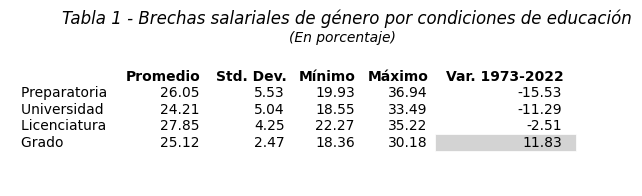

In [67]:
datos_tabla1 = [columna for columna in data2.columns if "year" not in columna if "white" not in columna if "black" not in columna if "hisp" not in columna if "men" not in columna if "mujer" not in columna if "high_school" not in columna if "some_college" not in columna if "bachelors_degree" not in columna if "advanced_degree" not in columna]
data2_select1 = data2[datos_tabla1]
data2_select1.head()

data2_select1.columns = data2_select1.columns.str.replace('brecha_', '')
data2_select1.columns = data2_select1.columns.str.replace('hs_', 'Preparatoria ')
data2_select1.columns = data2_select1.columns.str.replace('hs', 'Preparatoria ')

data2_select1.columns = data2_select1.columns.str.replace('sc_', 'Universidad ')
data2_select1.columns = data2_select1.columns.str.replace('sc', 'Universidad ')

data2_select1.columns = data2_select1.columns.str.replace('bachelors_', 'Licenciatura ')
data2_select1.columns = data2_select1.columns.str.replace('bach_', 'Licenciatura ')
data2_select1.columns = data2_select1.columns.str.replace('bach', 'Licenciatura ')
data2_select1.columns = data2_select1.columns.str.replace('advanced_', 'Grado ')
data2_select1.columns = data2_select1.columns.str.replace('adv_', 'Grado ')
data2_select1.columns = data2_select1.columns.str.replace('adv', 'Grado ')

estadisticas1 = {
    'Promedio': data2_select1.mean(),
    'Std. Dev.': data2_select1.std(),
    'Mínimo': data2_select1.min(),
    'Máximo': data2_select1.max(),
    'Var. 1973-2022': data2_select1.iloc[-1] - data2_select1.iloc[0]}

data2_estadisticas1 = pd.DataFrame(estadisticas1)
data2_estadisticas1 = data2_estadisticas1.round(2)

plt.figure(figsize=(4, 2))
tabla = plt.table(cellText=data2_estadisticas1.values,
                  colLabels=data2_estadisticas1.columns,
                  rowLabels=data2_estadisticas1.index,
                  loc='center')
tabla.auto_set_font_size(False)  # PARA PONER MI PROPIO TAMANO DE FUENTE
tabla.set_fontsize(10)
tabla.auto_set_column_width(col=list(range(len(data2_estadisticas1.columns)))) 

plt.axis('off')  
for key, cell in tabla._cells.items():
    cell.set_linewidth(0.5)  # DETERMINAR EL ANCHO DE LAS LINAS
    cell.set_edgecolor('white')  # COLOR DE LAS LINEAS

var_1973_2022_column = data2_estadisticas1['Var. 1973-2022']
for i, valor in enumerate(var_1973_2022_column):
    cell = tabla._cells[(i+1, len(data2_estadisticas1.columns)-1)]  # Índice de columna 'Var. 1973-2022'
    if valor > 0:      # SI EL VALOR ES POSITIVO, SE PINTA DE GRIS = BRECHA PERSISTE
        cell.set_facecolor('lightgray')
    elif valor < 0:     # SI VALOR ES NEGATIVO, SE QUEDA BLANCO = SE CIERRA BRECHA
        cell.set_facecolor('white')

for j, col_label in enumerate(data2_estadisticas1.columns):
    cell = tabla._cells[0, j]  # Las etiquetas de las columnas están en la fila 0
    cell.set_text_props(fontweight='bold')

plt.suptitle('(En porcentaje)', fontsize=10, fontstyle='italic', y=0.89)
plt.title('Tabla 1 - Brechas salariales de género por condiciones de educación',fontdict={'fontsize': 12, 'fontstyle': 'italic'})
plt.show()

        

#### TABLA2

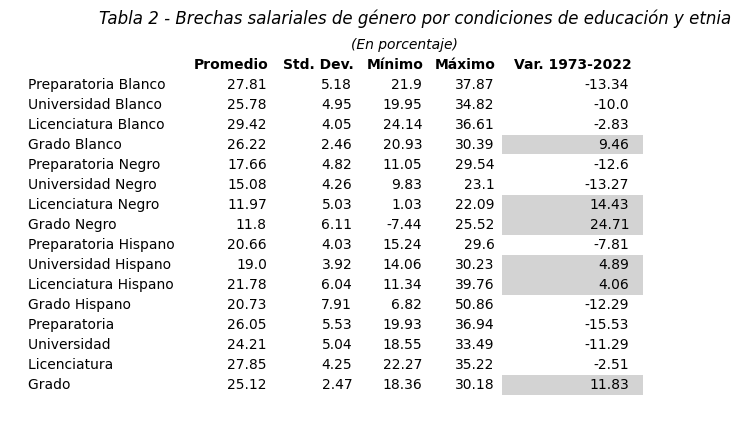

In [155]:
plt.figure(figsize=(8, 5))
tabla = plt.table(cellText=data2_estadisticas.values,
                  colLabels=data2_estadisticas.columns,
                  rowLabels=data2_estadisticas.index,
                  loc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.auto_set_column_width(col=list(range(len(data2_estadisticas.columns))))  # Ajustar el ancho de las columnas automáticamente

tabla.scale(1.2, 1.2)

plt.axis('off')  
for key, cell in tabla._cells.items():
    if key[0] == 0:  # Solo afectar las celdas en la fila 0 (etiquetas de columnas)
        cell.set_linewidth(1.5)  # Establecer el ancho de la línea del borde de la celda
    else:
        cell.set_linewidth(0)  # Establecer el ancho de la línea del borde de la celda a 0 para las celdas horizontales
    cell.set_edgecolor('white')  # Establecer el color del borde de la celda

# CONDICIONAL DE VALORES NEGATIVOS Y POSITIVOS
var_1973_2022_column = data2_estadisticas['Var. 1973-2022']
for i, valor in enumerate(var_1973_2022_column):
    cell = tabla._cells[(i+1, len(data2_estadisticas.columns)-1)]  # Índice de columna 'Var. 1973-2022'
    if valor > 0:
        cell.set_facecolor('lightgrey')
    elif valor < 0:
        cell.set_facecolor('white')

# HACE QUE LOS NOMBRES DE LAS COLUMNAS TIENEN BOLD
for j, col_label in enumerate(data2_estadisticas.columns):
    cell = tabla._cells[0, j]  # Las etiquetas de las columnas están en la fila 0
    cell.set_text_props(fontweight='bold')

plt.suptitle('(En porcentaje)', fontsize=10, fontstyle='italic', y=0.87)
plt.title('Tabla 2 - Brechas salariales de género por condiciones de educación y etnia',fontdict={'fontsize': 12, 'fontstyle': 'italic'})
plt.show()

#### TABLA3

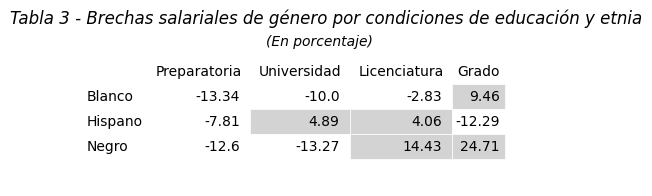

In [156]:
# TABLA SOBRE CAMBIO EN LA BRECHA ENTRE 1973-2022

# LISTA PARA DATOS QUE QUIERO
data_desagregado = []

# PARA CADA DATO QUE QUIERO...
for educacion in ['Preparatoria', 'Universidad', 'Licenciatura', 'Grado']:
    for etnia in ['Blanco', 'Negro', 'Hispano']:
        valor = data2_estadisticas.loc[f'{educacion} {etnia}', 'Var. 1973-2022']
        data_desagregado.append({'Educación': educacion, 'Etnia': etnia, 'Valor': valor})

# DATAFRAME DE LISTA EDUC Y ETNIA
data_desagregado = pd.DataFrame(data_desagregado)

# Reordenar las columnas según el nuevo orden
column_order = ['Preparatoria', 'Universidad', 'Licenciatura', 'Grado']
data_desagregado = data_desagregado.pivot(index='Etnia', columns='Educación', values='Valor').reindex(columns=column_order)

# TABLA
plt.figure(figsize=(5, 2))
tabla = plt.table(cellText=data_desagregado.values,
                  colLabels=data_desagregado.columns,
                  rowLabels=data_desagregado.index,
                  loc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.auto_set_column_width(col=list(range(len(data_desagregado.columns))))  # Ajustar el ancho de las columnas automáticamente

tabla.scale(1.5, 1.5)

plt.axis('off')

for key, cell in tabla._cells.items():
    cell.set_linewidth(0.5)  # Establecer el ancho de la línea del borde de la celda
    cell.set_edgecolor('white')  # Establecer el color del borde de la celda

# Obtener el valor de la celda y cambiar el color de fondo si es un número
    if key[0] != 0 and key[1] != 0:  # Evitar la primera fila y la primera columna que contienen etiquetas
        valor = cell.get_text().get_text()
        if valor.replace('.', '', 1).isdigit():
            valor = float(valor)
            if valor > 0:
                cell.set_facecolor('lightgrey')

plt.suptitle('(En porcentaje)', fontsize=10, fontstyle='italic', y=0.87)
plt.title('Tabla 3 - Brechas salariales de género por condiciones de educación y etnia',fontdict={'fontsize': 12, 'fontstyle': 'italic'})
plt.show()

### **GRAFICAS**

#### Datos

In [71]:
data2.head()

,year,high_school,some_college,bachelors_degree,advanced_degree,men_high_school,men_some_college,men_bachelors_degree,men_advanced_degree,mujer_high_school,...,brecha_bach_black,brecha_adv_black,brecha_hs_hisp,brecha_sc_hisp,brecha_bach_hisp,brecha_adv_hisp,brecha_hs,brecha_sc,brecha_bach,brecha_adv
49,1973,22.22,24.08,32.80,38.16,26.90,27.67,37.69,40.09,16.97,...,6.001326,0.806643,26.353468,14.140127,20.889680,41.093640,36.914498,33.465847,32.342796,18.358693
48,1974,21.60,23.32,31.69,38.37,26.15,26.79,36.62,41.03,16.49,...,5.602716,12.097612,27.696405,17.968397,34.520217,12.299114,36.940727,33.146697,32.550519,24.981721
47,1975,21.55,23.30,31.45,38.41,26.02,26.93,36.21,40.86,16.54,...,1.027640,15.653728,27.974854,27.023555,39.757111,10.897436,36.433513,33.494244,32.504833,21.341165
46,1976,21.76,23.49,31.46,37.50,26.14,27.10,36.42,40.31,17.01,...,10.185822,11.884936,25.280899,24.773022,33.344284,50.857009,34.927314,32.214022,32.674355,22.971967
45,1977,21.50,22.97,31.07,37.36,25.97,26.70,36.09,40.56,16.71,...,11.510791,-7.442803,24.241091,26.993603,36.626364,7.928311,35.656527,32.883895,33.832086,25.221893


In [147]:
data3 = data2[[columna for columna in data2.columns if 'brecha' not in columna]]  # Usamos [[]] para mantener el DataFrame, no solo las columnas
if 'year' in data2.columns: 
    data3['year'] = data2['year']  # Añadimos 'year' directamente al DataFrame

# Reemplazamos los nombres de las columnas
data3.columns = data3.columns.str.replace('_', ' ')
data3.columns = data3.columns.str.replace('high school', 'Preparatoria')
data3.columns = data3.columns.str.replace('some college', 'Universidad')
data3.columns = data3.columns.str.replace('bachelors degree', 'Licenciatura')
data3.columns = data3.columns.str.replace('advanced degree', 'Grado')

data3.columns = data3.columns.str.replace('black', 'Negros')
data3.columns = data3.columns.str.replace('mujer', 'Mujeres')
data3.columns = data3.columns.str.replace('men', 'Hombres')
data3.columns = data3.columns.str.replace('white', 'Blancos')
data3.columns = data3.columns.str.replace('hispanic', 'Hispanos')

# Realizamos los cálculos y asignaciones utilizando .loc
data3.loc[:, '100'] = ((data3['Hombres Preparatoria'] / data3['Hombres Preparatoria']) * 100)

# PREPA
data3.loc[:, '%Mujeres prepa'] = round(((data3['Mujeres Preparatoria'] / data3['Hombres Preparatoria']) * 100), 2)
data3.loc[:, '%Mujeres prepa blanca'] = round(((data3['Blancos Mujeres Preparatoria'] / data3['Blancos Hombres Preparatoria']) * 100), 2)
data3.loc[:, '%Mujeres prepa negra'] = round(((data3['Negros Mujeres Preparatoria'] / data3['Negros Hombres Preparatoria']) * 100), 2)
data3.loc[:, '%Mujeres prepa hispanas'] = round(((data3['Hispanos Mujeres Preparatoria'] / data3['Hispanos Hombres Preparatoria']) * 100), 2)

# UNIVERSIDAD
data3.loc[:, '%Mujeres uni'] = round(((data3['Mujeres Universidad'] / data3['Hombres Universidad']) * 100), 2)
data3.loc[:, '%Mujeres uni blancas'] = round(((data3['Blancos Mujeres Universidad'] / data3['Blancos Hombres Universidad']) * 100), 2)
data3.loc[:, '%Mujeres uni negras'] = round(((data3['Negros Mujeres Universidad'] / data3['Negros Hombres Universidad']) * 100), 2)
data3.loc[:, '%Mujeres uni hispanas'] = round(((data3['Hispanos Mujeres Universidad'] / data3['Hispanos Hombres Universidad']) * 100), 2)

# LICENCIATURA
data3.loc[:, '%Mujeres lic'] = round(((data3['Mujeres Licenciatura'] / data3['Hombres Licenciatura']) * 100), 2)
data3.loc[:, '%Mujeres lic blancas'] = round(((data3['Blancos Mujeres Licenciatura'] / data3['Blancos Hombres Licenciatura']) * 100), 2)
data3.loc[:, '%Mujeres lic negras'] = round(((data3['Negros Mujeres Licenciatura'] / data3['Negros Hombres Licenciatura']) * 100), 2)
data3.loc[:, '%Mujeres lic hispanas'] = round(((data3['Hispanos Mujeres Licenciatura'] / data3['Hispanos Hombres Licenciatura']) * 100), 2)

# GRADO
data3.loc[:, '%Mujeres grado'] = round(((data3['Mujeres Grado'] / data3['Hombres Grado']) * 100), 2)
data3.loc[:, '%Mujeres grado blancas'] = round(((data3['Blancos Mujeres Grado'] / data3['Blancos Hombres Grado']) * 100), 2)
data3.loc[:, '%Mujeres grado negras'] = round(((data3['Negros Mujeres Grado'] / data3['Negros Hombres Grado']) * 100), 2)
data3.loc[:, '%Mujeres grado hispanas'] = round(((data3['Hispanos Mujeres Grado'] / data3['Hispanos Hombres Grado']) * 100), 2)

data3.head()

C:\Users\hashi\AppData\Local\Temp\ipykernel_18256\39609450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data3['year'] = data2['year']  # Añadimos 'year' directamente al DataFrame
C:\Users\hashi\AppData\Local\Temp\ipykernel_18256\39609450.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data3.loc[:, '100'] = ((data3['Hombres Preparatoria'] / data3['Hombres Preparatoria']) * 100)
C:\Users\hashi\AppData\Local\Temp\ipykernel_18256\39609450.py:22: SettingWithCopyWarning: 
A value is trying to be set o

,year,Preparatoria,Universidad,Licenciatura,Grado,Hombres Preparatoria,Hombres Universidad,Hombres Licenciatura,Hombres Grado,Mujeres Preparatoria,...,%Mujeres uni negras,%Mujeres uni hispanas,%Mujeres lic,%Mujeres lic blancas,%Mujeres lic negras,%Mujeres lic hispanas,%Mujeres grado,%Mujeres grado blancas,%Mujeres grado negras,%Mujeres grado hispanas
49,1973,22.22,24.08,32.80,38.16,26.90,27.67,37.69,40.09,16.97,...,76.90,85.86,67.66,66.09,94.00,79.11,81.64,79.07,99.19,58.91
48,1974,21.60,23.32,31.69,38.37,26.15,26.79,36.62,41.03,16.49,...,80.17,82.03,67.45,66.16,94.40,65.48,75.02,74.19,87.90,87.70
47,1975,21.55,23.30,31.45,38.41,26.02,26.93,36.21,40.86,16.54,...,76.93,72.98,67.50,65.95,98.97,60.24,78.66,78.74,84.35,89.10
46,1976,21.76,23.49,31.46,37.50,26.14,27.10,36.42,40.31,17.01,...,77.78,75.23,67.33,65.82,89.81,66.66,77.03,76.39,88.12,49.14
45,1977,21.50,22.97,31.07,37.36,25.97,26.70,36.09,40.56,16.71,...,82.91,73.01,66.17,65.01,88.49,63.37,74.78,71.20,107.44,92.07


#### Graficas SALARIOS

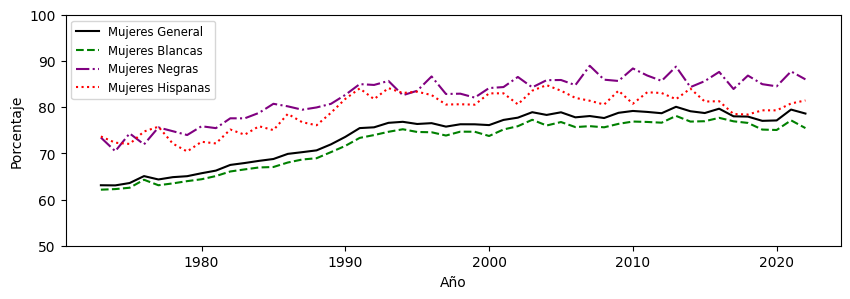

In [150]:
# GRAFICA 1 - SALARIOS MUJERES 
plt.figure(figsize=(10, 3))

plt.plot(data3['year'], data3['%Mujeres prepa'], label='Mujeres General', color='black', linestyle='-')
plt.plot(data3['year'], data3['%Mujeres prepa blanca'], label='Mujeres Blancas', color='green', linestyle='--')
plt.plot(data3['year'], data3['%Mujeres prepa negra'], label='Mujeres Negras', color='purple', linestyle='-.')
plt.plot(data3['year'], data3['%Mujeres prepa hispanas'], label='Mujeres Hispanas', color='red', linestyle=':')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=50, top=100)
plt.xlabel('Año')
plt.ylabel('Porcentaje')

plt.legend(fontsize='small')
plt.show()

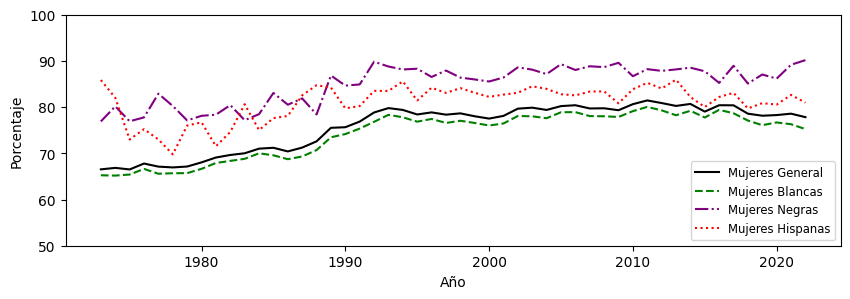

In [151]:
# GRAFICA 2 - SALARIOS MUJERES UNI
plt.figure(figsize=(10, 3))

plt.plot(data3['year'], data3['%Mujeres uni'], label='Mujeres General', color='black', linestyle='-')
plt.plot(data3['year'], data3['%Mujeres uni blancas'], label='Mujeres Blancas', color='green', linestyle='--')
plt.plot(data3['year'], data3['%Mujeres uni negras'], label='Mujeres Negras', color='purple', linestyle='-.')
plt.plot(data3['year'], data3['%Mujeres uni hispanas'], label='Mujeres Hispanas', color='red', linestyle=':')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=50, top=100)
plt.xlabel('Año')
plt.ylabel('Porcentaje')

plt.legend(fontsize='small')

plt.show()

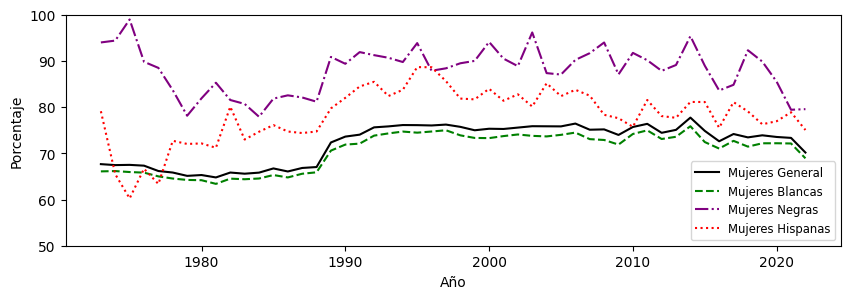

In [152]:
# GRAFICA 3 - SALARIOS MUJERES LIC
plt.figure(figsize=(10, 3))

plt.plot(data3['year'], data3['%Mujeres lic'], label='Mujeres General', color='black', linestyle='-')
plt.plot(data3['year'], data3['%Mujeres lic blancas'], label='Mujeres Blancas', color='green', linestyle='--')
plt.plot(data3['year'], data3['%Mujeres lic negras'], label='Mujeres Negras', color='purple', linestyle='-.')
plt.plot(data3['year'], data3['%Mujeres lic hispanas'], label='Mujeres Hispanas', color='red', linestyle=':')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=50, top=100)
plt.xlabel('Año')
plt.ylabel('Porcentaje')


plt.legend(fontsize='small')

plt.show()

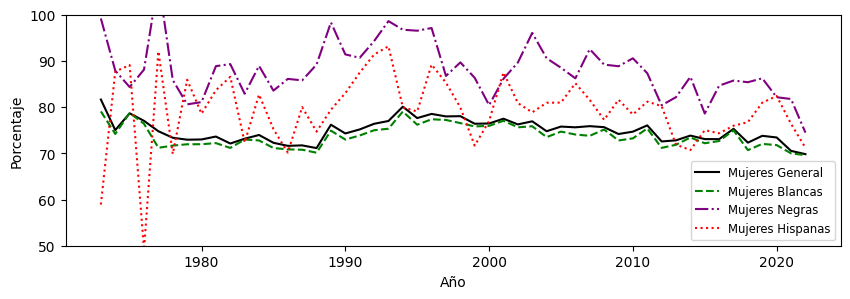

In [153]:
# GRAFICA 4 - SALARIOS MUJERES LIC
plt.figure(figsize=(10, 3))

plt.plot(data3['year'], data3['%Mujeres grado'], label='Mujeres General', color='black', linestyle='-')
plt.plot(data3['year'], data3['%Mujeres grado blancas'], label='Mujeres Blancas', color='green', linestyle='--')
plt.plot(data3['year'], data3['%Mujeres grado negras'], label='Mujeres Negras', color='purple', linestyle='-.')
plt.plot(data3['year'], data3['%Mujeres grado hispanas'], label='Mujeres Hispanas', color='red', linestyle=':')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=50, top=100)
plt.xlabel('Año')
plt.ylabel('Porcentaje')

plt.legend(fontsize='small')

plt.show()

#### Graficas BRECHAS

In [ ]:
brechas = [columna for columna in data2.columns if 'brecha' in columna]
if 'year' in data2.columns:
    brechas.append('year')
data4 = data2[brechas]
data4.head()


,brecha_hs_white,brecha_sc_white,brecha_bach_white,brecha_adv_white,brecha_hs_black,brecha_sc_black,brecha_bach_black,brecha_adv_black,brecha_hs_hisp,brecha_sc_hisp,brecha_bach_hisp,brecha_adv_hisp,brecha_hs,brecha_sc,brecha_bach,brecha_adv,year
49,37.872186,34.753284,33.907596,20.929654,26.592283,23.099788,6.001326,0.806643,26.353468,14.140127,20.889680,41.093640,36.914498,33.465847,32.342796,18.358693,1973
48,37.743628,34.822409,33.837838,25.808806,29.542365,19.832525,5.602716,12.097612,27.696405,17.968397,34.520217,12.299114,36.940727,33.146697,32.550519,24.981721,1974
47,37.448250,34.585918,34.049497,21.261568,25.690220,23.067120,1.027640,15.653728,27.974854,27.023555,39.757111,10.897436,36.433513,33.494244,32.504833,21.341165,1975
46,35.716974,33.369684,34.183397,23.613861,28.070175,22.222222,10.185822,11.884936,25.280899,24.773022,33.344284,50.857009,34.927314,32.214022,32.674355,22.971967,1976
45,36.911488,34.423218,34.993160,28.801562,24.397032,17.091388,11.510791,-7.442803,24.241091,26.993603,36.626364,7.928311,35.656527,32.883895,33.832086,25.221893,1977


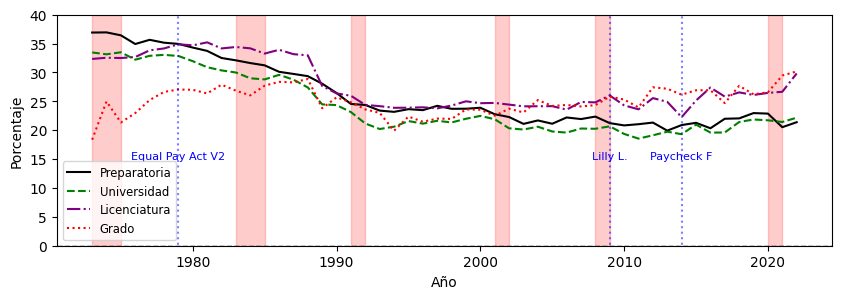

In [154]:
# GRAFICA 5 - BRECHAS POR EDUCACION

recessions = [(1973, 1975),(1983, 1985),(1991,1992),(2001, 2002), (2008, 2009),(2020, 2021)]
plt.figure(figsize=(10, 3))

plt.plot(data4['year'], data4['brecha_hs'], label='Preparatoria', color='black', linestyle='-')
plt.plot(data4['year'], data4['brecha_sc'], label='Universidad', color='green', linestyle='--')
plt.plot(data4['year'], data4['brecha_bach'], label='Licenciatura', color='purple', linestyle='-.')
plt.plot(data4['year'], data4['brecha_adv'], label='Grado', color='red', linestyle=':')

# REMARCAR RECESIONES
for start, end in recessions:
    plt.fill_between(range(start, end+1), -10, 40, color='red', alpha=0.2)

# Años de promulgación de leyes
leyes = {
    1979: 'Equal Pay Act V2',
    2009: 'Lilly L.',
    2014: 'Paycheck F'
}

# Agregar líneas verticales azules y texto para las leyes
for year, ley_text in leyes.items():
    plt.vlines(year, -10, 40, colors='blue', linestyles='dotted', alpha=0.5)
    plt.text(year, 15 , ley_text, color='blue', fontsize=8, ha='center')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=0, top=40)
plt.xlabel('Año')
plt.ylabel('Porcentaje')

plt.legend(fontsize='small')

plt.show()

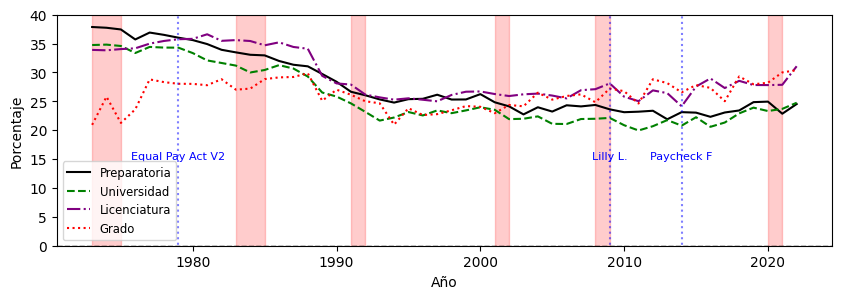

In [99]:
# GRAFICA 6 - BRECHAS POR BLANCOS EDUCACION

recessions = [(1973, 1975),(1983, 1985),(1991,1992),(2001, 2002), (2008, 2009),(2020, 2021)]

plt.figure(figsize=(10, 3))

plt.plot(data4['year'], data4['brecha_hs_white'], label='Preparatoria', color='black', linestyle='-')
plt.plot(data4['year'], data4['brecha_sc_white'], label='Universidad', color='green', linestyle='--')
plt.plot(data4['year'], data4['brecha_bach_white'], label='Licenciatura', color='purple', linestyle='-.')
plt.plot(data4['year'], data4['brecha_adv_white'], label='Grado', color='red', linestyle=':')

# REMARCAR RECESIONES
for start, end in recessions:
    plt.fill_between(range(start, end+1), -10, 40, color='red', alpha=0.2)

# Años de promulgación de leyes
leyes = {
    1979: 'Equal Pay Act V2',
    2009: 'Lilly L.',
    2014: 'Paycheck F'
}

# Agregar líneas verticales azules y texto para las leyes
for year, ley_text in leyes.items():
    plt.vlines(year, -10, 40, colors='blue', linestyles='dotted', alpha=0.5)
    plt.text(year, 15 , ley_text, color='blue', fontsize=8, ha='center')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=0, top=40)
plt.xlabel('Año')
plt.ylabel('Porcentaje')

plt.legend(fontsize='small')

plt.show()

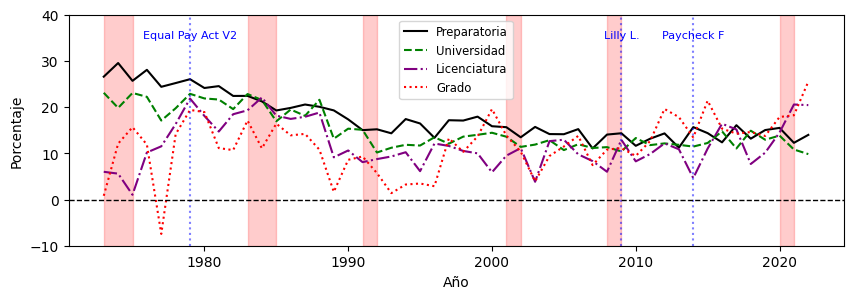

In [100]:
# GRAFICA 7 - BRECHAS POR BLANCOS EDUCACION
recessions = [(1973, 1975),(1983, 1985),(1991,1992),(2001, 2002), (2008, 2009),(2020, 2021)]

plt.figure(figsize=(10, 3))

plt.plot(data4['year'], data4['brecha_hs_black'], label='Preparatoria', color='black', linestyle='-')
plt.plot(data4['year'], data4['brecha_sc_black'], label='Universidad', color='green', linestyle='--')
plt.plot(data4['year'], data4['brecha_bach_black'], label='Licenciatura', color='purple', linestyle='-.')
plt.plot(data4['year'], data4['brecha_adv_black'], label='Grado', color='red', linestyle=':')

# REMARCAR RECESIONES
for start, end in recessions:
    plt.fill_between(range(start, end+1), -10, 40, color='red', alpha=0.2)
    
# Años de promulgación de leyes
leyes = {
    1979: 'Equal Pay Act V2',
    2009: 'Lilly L.',
    2014: 'Paycheck F'
}

# Agregar líneas verticales azules y texto para las leyes
for year, ley_text in leyes.items():
    plt.vlines(year, -10, 40, colors='blue', linestyles='dotted', alpha=0.5)
    plt.text(year, 35 , ley_text, color='blue', fontsize=8, ha='center')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=-10, top=40)
plt.xlabel('Año')
plt.ylabel('Porcentaje')


plt.legend(fontsize='small')

plt.show()

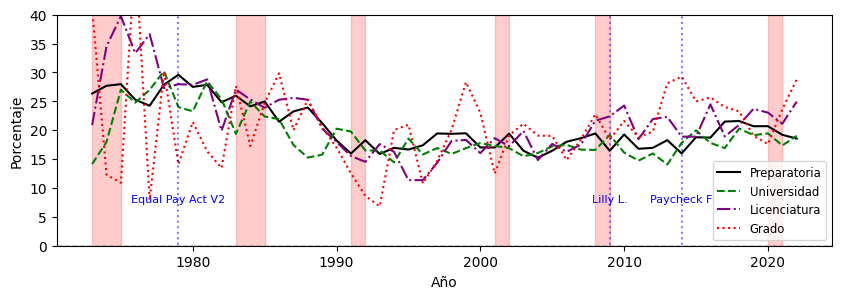

In [101]:
# GRAFICA 8 - BRECHAS POR BLANCOS EDUCACION
recessions = [(1973, 1975),(1983, 1985),(1991,1992),(2001, 2002), (2008, 2009),(2020, 2021)]

plt.figure(figsize=(10, 3))

plt.plot(data4['year'], data4['brecha_hs_hisp'], label='Preparatoria', color='black', linestyle='-')
plt.plot(data4['year'], data4['brecha_sc_hisp'], label='Universidad', color='green', linestyle='--')
plt.plot(data4['year'], data4['brecha_bach_hisp'], label='Licenciatura', color='purple', linestyle='-.')
plt.plot(data4['year'], data4['brecha_adv_hisp'], label='Grado', color='red', linestyle=':')

# REMARCAR RECESIONES
for start, end in recessions:
    plt.fill_between(range(start, end+1), -10, 40, color='red', alpha=0.2)
    
# Años de promulgación de leyes
leyes = {
    1979: 'Equal Pay Act V2',
    2009: 'Lilly L.',
    2014: 'Paycheck F'
}

# Agregar líneas verticales azules y texto para las leyes
for year, ley_text in leyes.items():
    plt.vlines(year, -10, 40, colors='blue', linestyles='dotted', alpha=0.5)
    plt.text(year, 7.5, ley_text, color='blue', fontsize=8, ha='center')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(bottom=0, top=40)
plt.xlabel('Año')
plt.ylabel('Porcentaje')

plt.legend(fontsize='small')

plt.show()

### **HEAT MAP**

In [ ]:
# SE CRE UN NUEVO DATA FRAME SOLO CON LAS VARIABLES DE INTERES

# DE GRAFICA 6 - BRECHAS SALARIALES PARA POBLACION GENERAL POR NIVEL EDUCATIVO
interes_lic = ['year', 'brecha_bach', 'brecha_bach_white', 'brecha_bach_black', 'brecha_bach_hisp']
arimas_lic = data2[interes_lic]
arimas_lic = arimas_lic.set_index('year')  
arimas_lic.head()



,brecha_bach,brecha_bach_white,brecha_bach_black,brecha_bach_hisp
year,,,,
1973,32.342796,33.907596,6.001326,20.889680
1974,32.550519,33.837838,5.602716,34.520217
1975,32.504833,34.049497,1.027640,39.757111
1976,32.674355,34.183397,10.185822,33.344284
1977,33.832086,34.993160,11.510791,36.626364


In [ ]:
interes_adv = ['year', 'brecha_adv', 'brecha_adv_white', 'brecha_adv_black', 'brecha_adv_hisp']
arimas_adv = data2[interes_adv]
arimas_adv = arimas_adv.set_index('year')  
arimas_adv.head()

,brecha_adv,brecha_adv_white,brecha_adv_black,brecha_adv_hisp
year,,,,
1973,18.358693,20.929654,0.806643,41.093640
1974,24.981721,25.808806,12.097612,12.299114
1975,21.341165,21.261568,15.653728,10.897436
1976,22.971967,23.613861,11.884936,50.857009
1977,25.221893,28.801562,-7.442803,7.928311


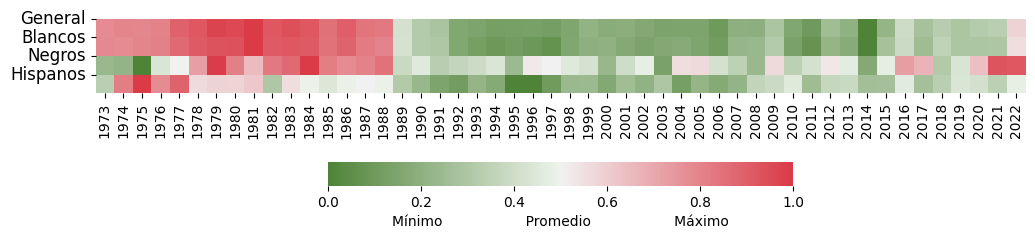

In [102]:
# Normalizar los datos (opcional pero recomendado)
arimas_normalized = (arimas_lic - arimas_lic.min()) / (arimas_lic.max() - arimas_lic.min())

# Definir una paleta de colores de verde a rojo
cmap = sns.diverging_palette(120, 10, as_cmap=True)

# Crear el mapa de calor horizontal con ejes invertidos
plt.figure(figsize=(12, 6))  # Ajusta el tamaño según tus preferencias
sns.heatmap(arimas_normalized.T, cmap=cmap, cbar_kws={'label': 'Mínimo                   Promedio                   Máximo','orientation': 'horizontal','shrink': 0.5},
            square=True)

plt.yticks(ticks=range(len(arimas_lic.columns)), labels=['General', 'Blancos', 'Negros', 'Hispanos'],fontsize=12)  # Cambia las etiquetas del eje y


# Ajustes adicionales (opcional)
plt.xlabel('')
plt.ylabel('')
plt.show()

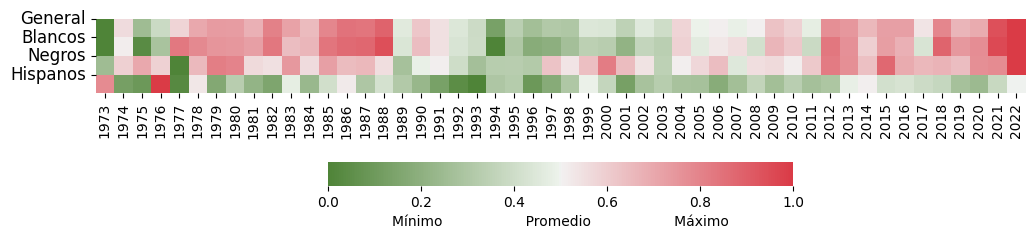

In [103]:
# Normalizar los datos (opcional pero recomendado)
arimas_normalized = (arimas_adv - arimas_adv.min()) / (arimas_adv.max() - arimas_adv.min())

# Definir una paleta de colores de verde a rojo
cmap = sns.diverging_palette(120, 10, as_cmap=True)

# Crear el mapa de calor horizontal con ejes invertidos
plt.figure(figsize=(12, 6))  # Ajusta el tamaño según tus preferencias
sns.heatmap(arimas_normalized.T, cmap=cmap, cbar_kws={'label': 'Mínimo                   Promedio                   Máximo','orientation': 'horizontal','shrink': 0.5},
            square=True)

plt.yticks(ticks=range(len(arimas_lic.columns)), labels=['General', 'Blancos', 'Negros', 'Hispanos'],fontsize=12)  # Cambia las etiquetas del eje y


# Ajustes adicionales (opcional)
plt.xlabel('')
plt.ylabel('')
plt.show()